# **Practical 5**

Welcome to the fifth practical for Graph Representation Learning (MT22). In this practical, we will be covering content from lecture 12.

We will be implementing the 1-WL hash algorithm and testing it on several graphs with different configurations.

The main goal of the practical is creating a working implementation of the 1-WL hash algorithm and understanding its applicability and limitations.

The notebook is divided into sections, each of which comes with complete or partially completed code. Before each snippet of code there will be a description of what we are about to implement. The sections of code you need to complete are marked as Tasks.

Please ensure that you operate within the framework given in the notebook and bring any questions you may have to the practical demonstrators. We suggest that you DO NOT edit code that is a part of the framework, since this will make it more difficult for demonstrators to assist if your code is broken.

In [1]:
# Check PyTorch version installed on this system
!python -c "import torch; print(torch.__version__)"

1.13.0+cu116


In [2]:
%%capture
# Download the corresponding PyTorch Geometric module
"""
Assign to TORCH with what you get from the cell above. E.g., export TORCH=1.12.1+cu113
"""
%env TORCH=1.12.1+cu113
!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-geometric
!pip install multiset
!pip install itertools

In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from torch_geometric.nn import Sequential, GCNConv, global_mean_pool#
from itertools import combinations
import networkx as nx
import multiset as ms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rng = np.random.default_rng()

# **Part 1: Weisfeiler Lehman Graph Hash**

This notebook is splitted in two parts. In Practical 5 we will be looking at the first half. Practical 6 will cover the second one.

## **Task 1.1: Generate graph pairs using NetworkX**

For $n$ between 6 and 15, generate all pairs of graphs $(\mathcal{C_n}, \mathcal{D}_{n,i}))$, where $\mathcal{C}_n$ is a cycle on $n$ nodes and $\mathcal{D}_{n,i}$ is the disjoint union of two cycles, with $n - i$ and $i$ nodes in total (of course the minimum number of nodes in each single connected component you build should be $> 2$). You can use the functions provided by networkx. We suggest you build on top of `networkx.cycle_graph`.

In [ ]:
# The range of different graph sizes
size_range = range(6, 16)

# The list of all graph pairs
graph_pairs = []

for n in size_range:
    c = nx.cycle_graph(n)
    for i in range(3, n - 2):
        d = nx.union(nx.cycle_graph(n - i), nx.cycle_graph(i), rename=("A", "B"))
        graph_pairs.append((c, d))



tensor([[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7],
        [1, 7, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 5, 7, 0, 6]])
tensor([[0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7],
        [1, 2, 0, 2, 0, 1, 4, 7, 3, 5, 4, 6, 5, 7, 3, 6]])


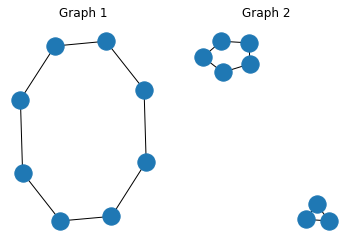

In [ ]:
### DO NOT MODIFY

# Display a random pair
fig, axs = plt.subplots(1, 2)
pair = random.choice(graph_pairs)
for i in range(2):
    nx.draw(pair[i], ax=axs[i])
    g = from_networkx(pair[i])
    print(g.edge_index)
    axs[i].set_title(f"Graph {i+1}")
plt.show()

## **Task 1.2: Implement the Weisfeiler Lehman (WL) graph hash**

Implement the function `weisfeiler_lehman_graph_hash` that takes in input a graph $\mathcal{G}$ and return the hash $WL(\mathcal{G})$. Use the constant $c = 1$ as the label for each node. For this task, you **cannot** use the utilities provided by the networkx library (except to convert from graphs to tensors if necessary).

In [ ]:
def refine(node_c, nbh_c, rest_c):
    return hash((node_c, tuple(nbh_c), tuple(rest_c)))

def graph_colour(colours):
    l = list(colours)
    l.sort()
    return(hash(tuple(l)))

def isDone(colours, prev_colours):
    prev = list(map(lambda p: p[0] == p[1], combinations(prev_colours.tolist(), 2)))
    curr = list(map(lambda p: p[0] == p[1], combinations(colours.tolist(), 2)))
    return prev == curr

def weisfeiler_lehman_graph_hash(graph, init_colours = None):
    """Implements the 1-WL hash algorithm"""
    g = from_networkx(graph)
    n = g.num_nodes
    e = np.transpose(g.edge_index.numpy())
    nbh = np.split(e[:,1], np.unique(e[:, 0], return_index=True)[1][1:])
    all_nodes = np.array(list(range(n)))
    non_nbh = list(map(lambda a: np.setdiff1d(all_nodes, a), nbh))

    # Initial colouring
    if init_colours is None:
        colours = np.ones(n)
    else:
        colours = init_colours

    # Refine until done 
    done = False
    while not done:
        prev_colours = np.copy(colours)
        for (i,), node_c in np.ndenumerate(colours):
            nbh_c = list(prev_colours[nbh[i]])
            nbh_c.sort()
            rest_c = list(prev_colours[non_nbh[i]])
            rest_c.sort()
            colours[i] = refine(node_c, nbh_c, rest_c)
        done = isDone(colours, prev_colours)
    
    # Return graph level colouring
    return graph_colour(colours)
        
    

Let's do a sanity check to make sure that the members of each pair previously generated are 1-WL indistinguishable:

In [ ]:
### DO NOT MODIFY

wl_indistinguishable_pairs = 0
for pair in graph_pairs:
    hash0 = weisfeiler_lehman_graph_hash(pair[0])
    hash1 = weisfeiler_lehman_graph_hash(pair[1])
    # print(hash0)
    wl_indistinguishable_pairs += (hash0 == hash1)

# Print the number of pairs produced
print(f"Number of graph pairs: {len(graph_pairs)}")
print(f"Number of 1-WL indistinguishable pairs: {wl_indistinguishable_pairs}")

Number of graph pairs: 55
Number of 1-WL indistinguishable pairs: 55


# Part 2: WL with extra node information

## **Task 2.1: Updating the hash function**

Modify the `weisfeiler_lehman_graph_hash` to accept an optional extra element corresponding to the features to assign to each node to be used to compute the final hash.

### Task 2.1.1
Use the node degree as initial label to compute the WL hash. What do you expect to change compared to before? Why?

In [ ]:
def node_degrees(graph):
    """Returns a list with the degree of each node in graph"""
    g = from_networkx(graph)
    e = np.transpose(g.edge_index.numpy())
    nbh = np.split(e[:,1], np.unique(e[:, 0], return_index=True)[1][1:])
    degrees = np.array(list(map(lambda a: a.size, nbh)))
    return degrees

In [ ]:
### DO NOT MODIFY

wl_indistinguishable_pairs_with_degree = 0
for pair in graph_pairs:
    hash0 = weisfeiler_lehman_graph_hash(pair[0], node_degrees(pair[0]))
    hash1 = weisfeiler_lehman_graph_hash(pair[1], node_degrees(pair[1]))
    wl_indistinguishable_pairs_with_degree += (hash0 == hash1)

# Print the number of pairs produced
print(f"Number of graph pairs: {len(graph_pairs)}")
print(f"Number of 1-WL indistinguishable pairs when "
      f"using the node degree as label: {wl_indistinguishable_pairs_with_degree}")

Number of graph pairs: 55
Number of 1-WL indistinguishable pairs when using the node degree as label: 55


Result is as expected: all nodes have degrees 2, so this feature is not enough to distinguish the graphs

### Task 2.1.2
Modify the initial label of each node $N_i$ such that it now contains the shortest path length from $N_i$ to $N_j$. Run `weisfeiler_lehman_graph_hash` using the new labels.

In [ ]:
def node_shortest_paths(graph):
    s = list(nx.all_pairs_shortest_path_length(graph))
    s = [hash(tuple(sorted(d.values()))) for (i, d) in s]
    return np.array(s)

In [ ]:
### DO NOT MODIFY

wl_indistinguishable_pairs_with_shortest_path = 0
for pair in graph_pairs:
    hash0 = weisfeiler_lehman_graph_hash(pair[0], node_shortest_paths(pair[0]))
    hash1 = weisfeiler_lehman_graph_hash(pair[1], node_shortest_paths(pair[1]))
    wl_indistinguishable_pairs_with_shortest_path += (hash0 == hash1)

# Print the number of pairs produced
print(f"Number of graph pairs: {len(graph_pairs)}")
print(f"Number of 1-WL indistinguishable pairs when "
      f"using the shortest path lenghts as label: {wl_indistinguishable_pairs_with_shortest_path}")

Number of graph pairs: 55
Number of 1-WL indistinguishable pairs when using the shortest path lenghts as label: 0


## **Task 2.2 (Optional): Tricking the hash function.**

Can you find one pair of non-isomorphic hamiltonian graphs with $N=6$ nodes and $E=9$ edges that are indistinguishable by the 1-WL hash even when using the `node_shortest_paths` as initial node label? 
(They don't have to be cycles/union of disjoint cycles. Any two graphs would suffice. How many pairs of hamiltonian graphs with 6 nodes and 9 edges each exist?)

In [ ]:
def trick_1wl_with_shortest_path():
    """Produces two non-isomorphic networkx graphs that are indistinguishable by
    the 1-WL 'shortest-path' hash"""
    prism = nx.cycle_graph(6)
    prism.add_edge(0, 4)
    prism.add_edge(1, 3)
    prism.add_edge(2, 5)

    utilities = nx.complete_bipartite_graph(3, 3)

    return [prism, utilities]


You manage to trick the 1-WL hash: True


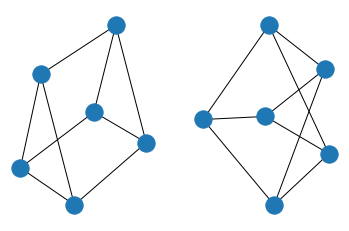

In [ ]:
### DO NOT MODIFY
pair = trick_1wl_with_shortest_path()

hash0 = weisfeiler_lehman_graph_hash(pair[0], node_shortest_paths(pair[0]))
hash1 = weisfeiler_lehman_graph_hash(pair[1], node_shortest_paths(pair[1]))
wl_indistinguishable_pairs_with_shortest_path = (hash0 == hash1)

print("You manage to trick the 1-WL hash:", wl_indistinguishable_pairs_with_shortest_path)

fig, axs = plt.subplots(1, 2)
for i in range(2):
    nx.draw(pair[i], ax=axs[i])
plt.show()

Are you sure the graphs you found are not isomorphic?

YES! prism is planar, utilities is not 

Number of Hamiltonian graphs with 6 nodes and 9 edges:
wlog start with C6: this is a hamiltonian cycle in the graph
We need to add 3 more edges
There are n choose 3 / 6 such options,
where n = 3*6
so 136